# Exploratory Data Analysis: GDELT 2.0 EVENT DATABASE


This notebook presents an exploratory analysis of the GDELT 2.0 EVENT DATABASE using a large representative sample drawn from the event population (up to 2025). For GDELT metadata, access GDELT_metadata.ipynb

- Why a sample instead of the entire available data? R: The entire data between 1971-2025 has 850M+ instances. Despite the fact tools like Polars would make the entire data EDA possible, it doesn't mean it would be feasible. Moreover, I'm using another [repository](https://github.com/Vinicius-Teixeirac/GDELT-2.0-EVENT-DATABASE-Pipeline) to obtain data, which in turns is limited by pandas + my hardware constraints.

- Is this sample i.i.d? R: Not in the statistical sense. The actual data we want for these experiments must not contain missing values on GlobalEventId, Actor1Name, Actor2Name, QuadClass, Actor1Geo_Lat, Actor1Geo_Long, Actor2Geo_Lat, Actor2Geo_Long,  ActionGeo_Lat, ActionGeo_Long and Day. A comprehensive discussion on this constraint is presented later. So the sample already reflects this behavior (as an representative EDA would require) reducing the original population from 850M+ to 540M+ instances. Moreover, the sampling methods are without replacement. By the way, this notebook doesn't intend to perform hypothesis testing neither other kind of analysis that would require i.i.d. samples.

It should present insights on data characteristics and guide methodological choices over smaller datasets, that will be used for evaluation due to hardware constraints. The smaller datasets used for evaluation were obtained via simple random sampling without replacement from the same cleaned population, going through the exact same filtering/sampling processes. Because each modeling dataset is comparatively small relative to the full dataset, the induced dependence between sampled observations is negligible. In practice, such sampling is commonly treated as producing approximately i.i.d. observations, and therefore the statistical properties observed in the larger sample are expected to generalize to the modeling datasets. 

No train/validation/test split is performed in this notebook. The analyses conducted here do not involve any modeling decisions that could introduce information leakage. Instead, the EDA serves solely to understand global properties of the data, identify potential quality issues, and inform feature engineering and preprocessing design choices in subsequent stages of the project.

## Notebook Setup

In [22]:
# cell: imports & config
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

current_dir = Path.cwd()
samples_path = Path("data/raw") 

# paths
DATA_DIR = current_dir.parent / samples_path
DATA_DIR.mkdir(parents=True, exist_ok=True)

## Data Loading

In [5]:
# cell: load a parquet sample file
fn = DATA_DIR / "sample_50000000.parquet"
df = pd.read_parquet(fn)
df.head()

,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,63,19790101,197901.0,1979.0,1979.0027,ATH,ATHEIST,None,None,None,...,-2959894,4.0,"Mongol, Khabarovskiy Kray, Russia",RS,RS30,52.1256,140.381,-2959894,20130203,None
1,90,19790101,197901.0,1979.0,1979.0027,CHLGOVMIL,CHILE,CHL,None,None,...,0,1.0,Chile,CI,CI,-30.0000,-71.000,0,20130203,None
2,105,19790101,197901.0,1979.0,1979.0027,CHN,CHINA,CHN,None,None,...,-2637939,4.0,"Republic Of China, Taiwan (general), Taiwan",TW,TW00,24.0000,121.000,-2637939,20130203,None
3,112,19790101,197901.0,1979.0,1979.0027,CHN,CHINA,CHN,None,None,...,0,4.0,"Peking, Beijing, China",CH,CH22,39.9289,116.388,-1898541,20130203,None
4,120,19790101,197901.0,1979.0,1979.0027,CHN,CHINA,CHN,None,None,...,10808006,4.0,"Cao Bang, Fujian, China",CH,CH07,26.5768,117.742,10808006,20130203,None


## Initial Analysis

In [6]:
# cell: basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000000 entries, 0 to 49999999
Data columns (total 58 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   GlobalEventID          int64  
 1   Day                    int64  
 2   MonthYear              float64
 3   Year                   float64
 4   FractionDate           float64
 5   Actor1Code             object 
 6   Actor1Name             object 
 7   Actor1CountryCode      object 
 8   Actor1KnownGroupCode   object 
 9   Actor1EthnicCode       object 
 10  Actor1Religion1Code    object 
 11  Actor1Religion2Code    object 
 12  Actor1Type1Code        object 
 13  Actor1Type2Code        object 
 14  Actor1Type3Code        object 
 15  Actor2Code             object 
 16  Actor2Name             object 
 17  Actor2CountryCode      object 
 18  Actor2KnownGroupCode   object 
 19  Actor2EthnicCode       object 
 20  Actor2Religion1Code    object 
 21  Actor2Religion2Code    object 
 22  Actor2Type1Code 

In [7]:
# cell: statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GlobalEventID,50000000.0,NaN,NaN,NaN,603898751.131792,386943739.071311,63.0,233648762.0,603945275.5,940852844.5,1281734982.0
Day,50000000.0,NaN,NaN,NaN,20153660.05953,77002.197906,19200101.0,20121215.0,20161123.0,20200811.0,20251231.0
MonthYear,50000000.0,NaN,NaN,NaN,201536.443334,770.021072,192001.0,201212.0,201611.0,202008.0,202512.0
Year,50000000.0,NaN,NaN,NaN,2015.299417,7.700544,1920.0,2012.0,2016.0,2020.0,2025.0
FractionDate,50000000.0,NaN,NaN,NaN,2015.79469,7.702616,1920.0027,2012.9452,2016.8849,2020.6055,2025.989
Actor1Code,49999953,18757,USA,6292356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor1Name,50000000,19561,UNITED STATES,4624958,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor1CountryCode,33452342,224,USA,8757178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor1KnownGroupCode,932650,64,UNO,321541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor1EthnicCode,333228,416,sco,25830,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# cell: first 5 rows
df.head()

,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,63,19790101,197901.0,1979.0,1979.0027,ATH,ATHEIST,None,None,None,...,-2959894,4.0,"Mongol, Khabarovskiy Kray, Russia",RS,RS30,52.1256,140.381,-2959894,20130203,None
1,90,19790101,197901.0,1979.0,1979.0027,CHLGOVMIL,CHILE,CHL,None,None,...,0,1.0,Chile,CI,CI,-30.0000,-71.000,0,20130203,None
2,105,19790101,197901.0,1979.0,1979.0027,CHN,CHINA,CHN,None,None,...,-2637939,4.0,"Republic Of China, Taiwan (general), Taiwan",TW,TW00,24.0000,121.000,-2637939,20130203,None
3,112,19790101,197901.0,1979.0,1979.0027,CHN,CHINA,CHN,None,None,...,0,4.0,"Peking, Beijing, China",CH,CH22,39.9289,116.388,-1898541,20130203,None
4,120,19790101,197901.0,1979.0,1979.0027,CHN,CHINA,CHN,None,None,...,10808006,4.0,"Cao Bang, Fujian, China",CH,CH07,26.5768,117.742,10808006,20130203,None


## Missing Data Analysis

Text(0.5, 1.0, 'Missing rate per column')

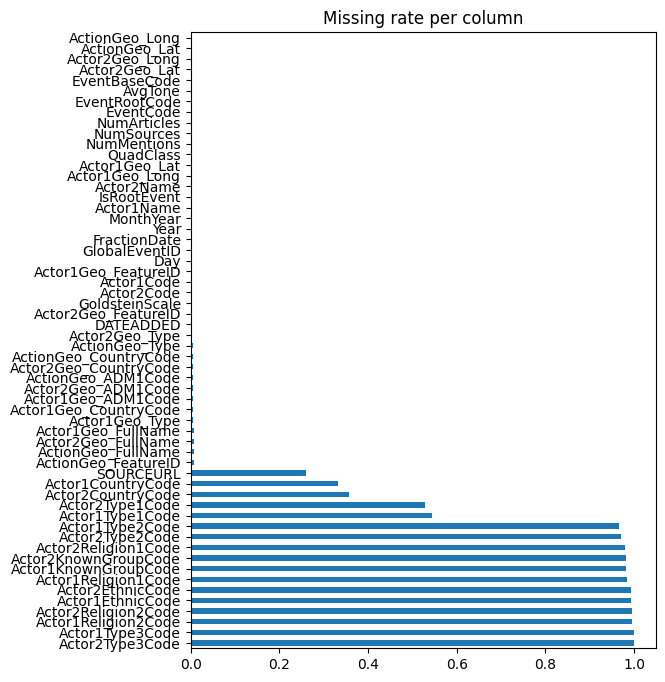

In [9]:
# cell: missing values per column
miss = df.isna().mean().sort_values(ascending=False)
miss.plot.barh(figsize=(6,8)); plt.title("Missing rate per column")

We can spot that, from the population of events without missing values on GlobalEventId, Actor1Name, Actor2Name, QuadClass, Actor1Geo_Lat, Actor1Geo_Long, Actor2Geo_Lat, Actor2Geo_Long,  ActionGeo_Lat, ActionGeo_Long and Day, there is still a large portion of missing values on Actor Attributes. Naturally, Date Attributes are not missing, what is related to the fact day is not missing in this population. The same idea applies to Geographic Attributes. SOURCEURL missingness is due the fact many news are from 1971-1990, before the age of the internet.

## Descriptive Statistics

### Numeric Features

In [10]:
# cell: numerical columns summary
numerical_cols = df.select_dtypes(include=['number'])
numerical_cols.describe().T

,count,mean,std,min,25%,50%,75%,max
GlobalEventID,50000000.0,6.038988e+08,3.869437e+08,6.300000e+01,2.336488e+08,6.039453e+08,9.408528e+08,1.281735e+09
Day,50000000.0,2.015366e+07,7.700220e+04,1.920010e+07,2.012122e+07,2.016112e+07,2.020081e+07,2.025123e+07
MonthYear,50000000.0,2.015364e+05,7.700211e+02,1.920010e+05,2.012120e+05,2.016110e+05,2.020080e+05,2.025120e+05
Year,50000000.0,2.015299e+03,7.700544e+00,1.920000e+03,2.012000e+03,2.016000e+03,2.020000e+03,2.025000e+03
FractionDate,50000000.0,2.015795e+03,7.702616e+00,1.920003e+03,2.012945e+03,2.016885e+03,2.020605e+03,2.025989e+03
IsRootEvent,50000000.0,6.218555e-01,4.849240e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
QuadClass,50000000.0,1.786321e+00,1.135748e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00
GoldsteinScale,49999718.0,5.555165e-01,4.707541e+00,-1.000000e+01,-2.000000e+00,1.900000e+00,3.400000e+00,1.000000e+01
NumMentions,50000000.0,9.736734e+00,5.277421e+01,1.000000e+00,2.000000e+00,4.000000e+00,8.000000e+00,7.031200e+04
NumSources,50000000.0,2.142668e+00,7.527792e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.165000e+03


In [11]:
float_cols = numerical_cols.select_dtypes(include=['float'])

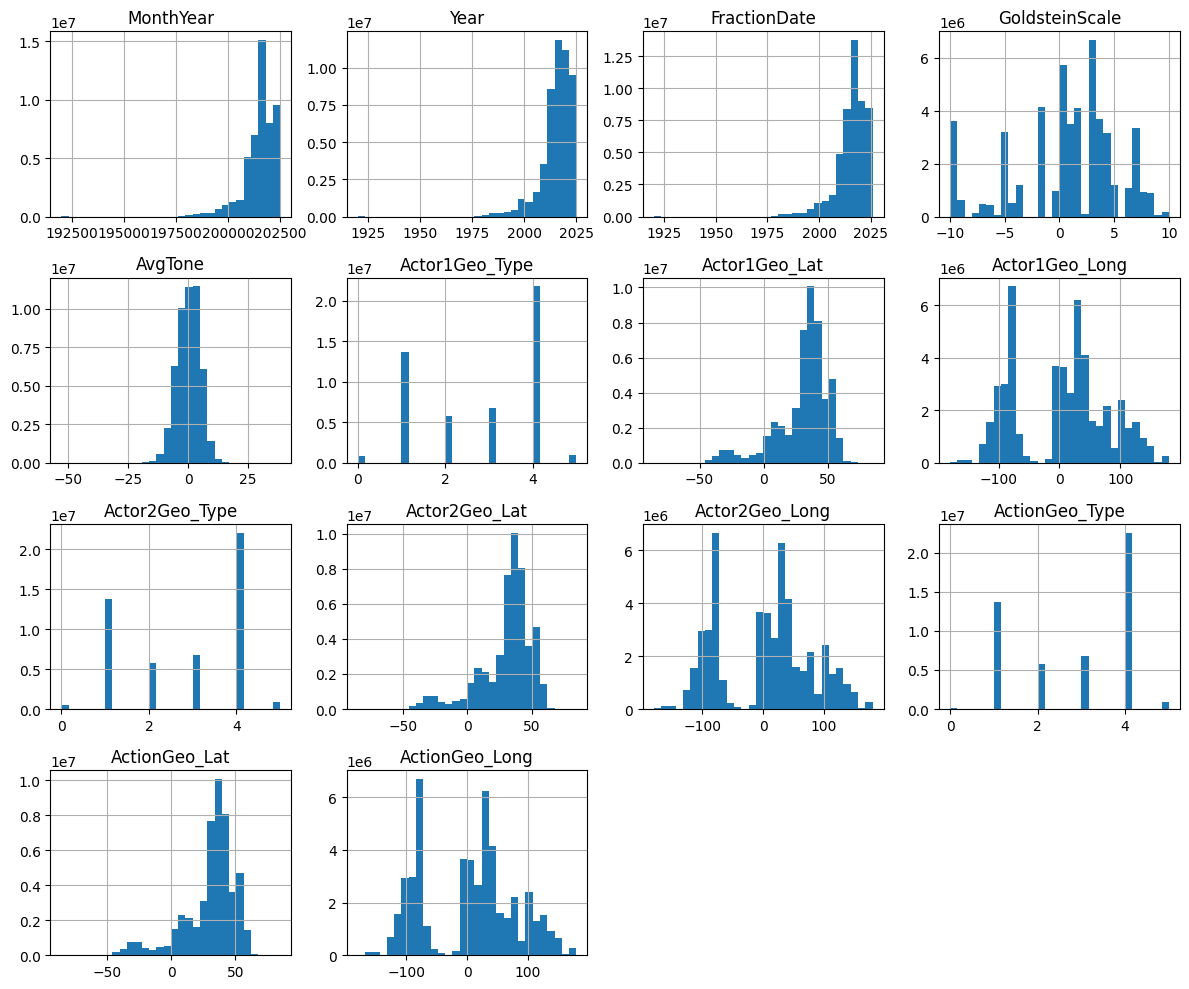

In [12]:
# cell: histogram of float columns
float_cols.hist(bins=30, figsize=(12,10))
plt.tight_layout()
plt.show()

In [13]:
integer_cols = numerical_cols.select_dtypes(include=['int']).columns

In [14]:
integer_cols 

Index(['GlobalEventID', 'Day', 'IsRootEvent', 'QuadClass', 'NumMentions',
       'NumSources', 'NumArticles'],
      dtype='object')

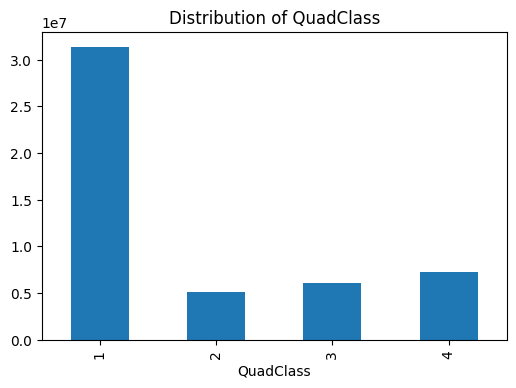

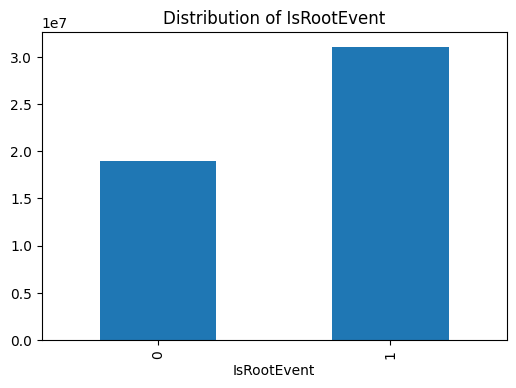

In [15]:
# cell: distribution plots for "numerical-categorical" columns
for col in ['QuadClass', 'IsRootEvent']:
    bar_plot = df[col].value_counts().sort_index().plot.bar(figsize=(6,4))
    bar_plot.set_title(f"Distribution of {col}")
    plt.show()

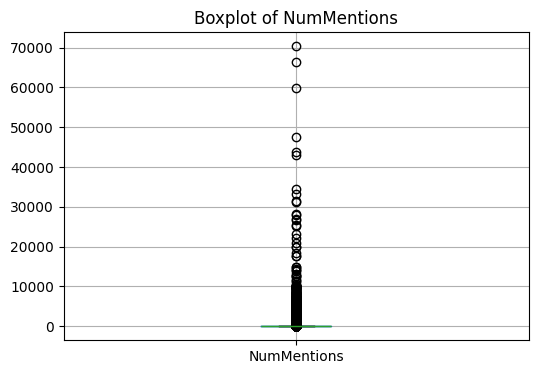

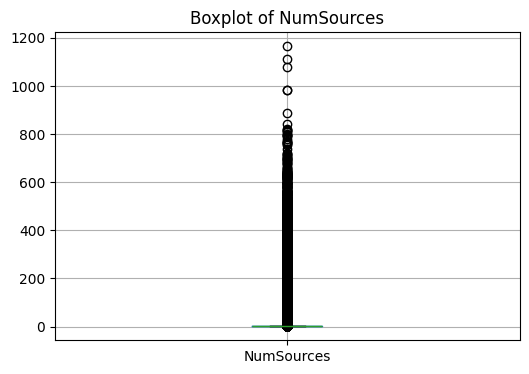

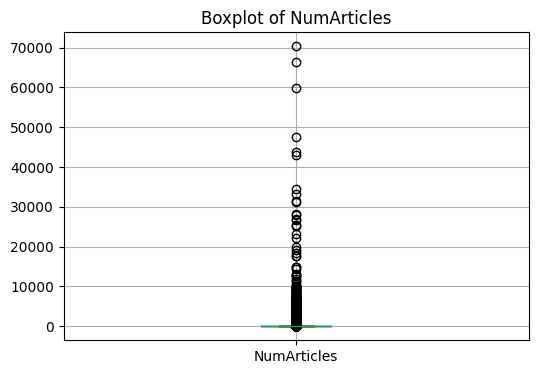

In [16]:
# cell: boxplots for integer columns
for col in ['NumMentions', 'NumSources', 'NumArticles']:
    box_plot = df.boxplot(column=col, figsize=(6,4))
    box_plot.set_title(f"Boxplot of {col}")
    plt.show()

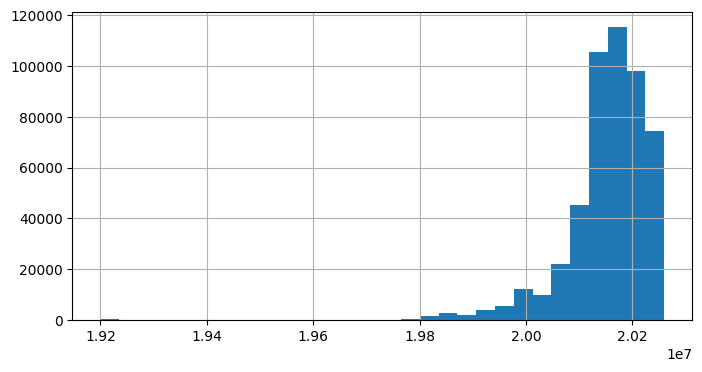

In [ ]:
# cell: histogram of 'Day' column
day_hist = df['Day'].hist(bins=30, figsize=(8,4))

### "Object" Features

In [29]:
categorical_cols = df.select_dtypes(include=['object'])
categorical_cols.describe().T

,count,unique,top,freq
Actor1Code,49999953,18757,USA,6292356
Actor1Name,50000000,19561,UNITED STATES,4624958
Actor1CountryCode,33452342,224,USA,8757178
Actor1KnownGroupCode,932650,64,UNO,321541
Actor1EthnicCode,333228,416,sco,25830
Actor1Religion1Code,838537,15,MOS,386172
Actor1Religion2Code,205704,20,CTH,97505
Actor1Type1Code,22802457,33,GOV,7650669
Actor1Type2Code,1660062,27,GOV,256275
Actor1Type3Code,55490,23,MIL,14586


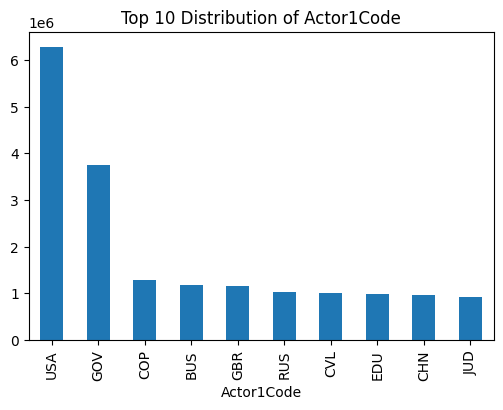

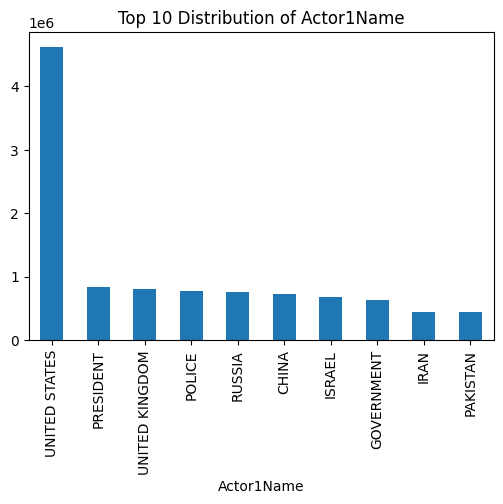

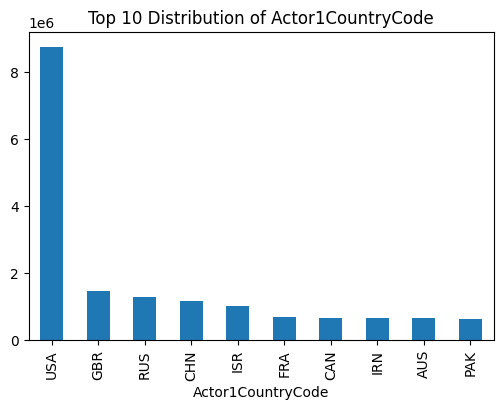

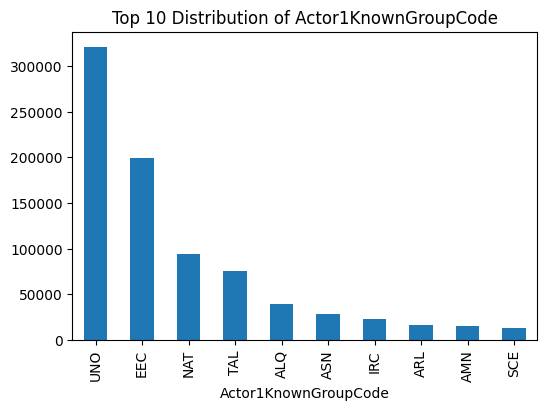

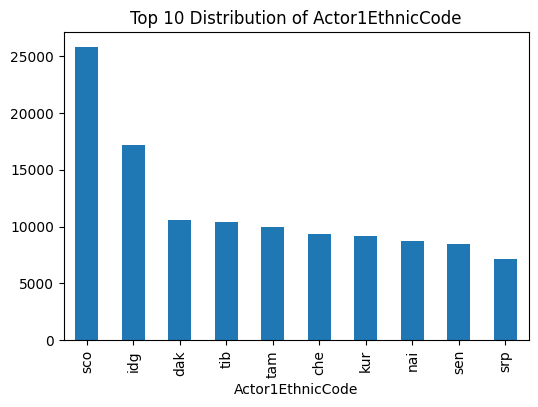

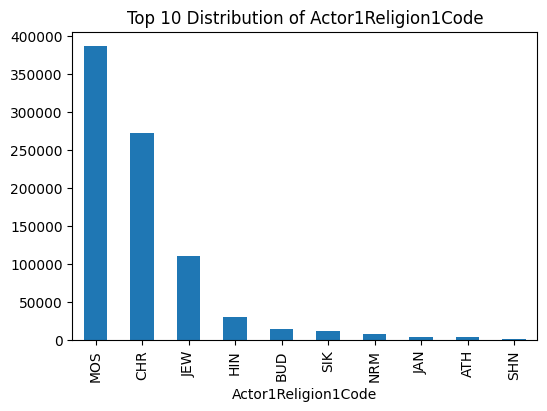

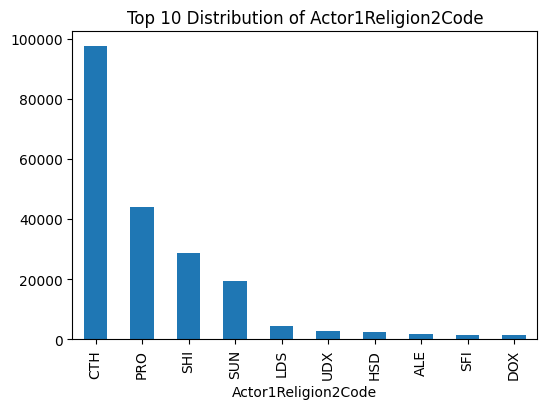

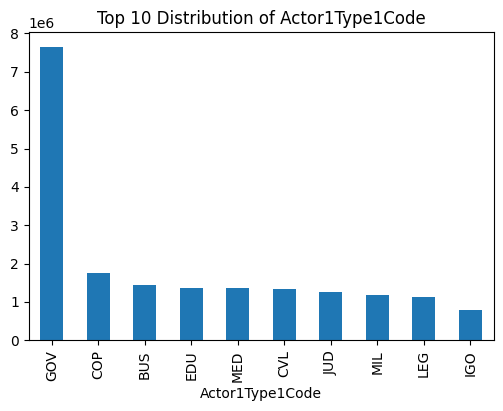

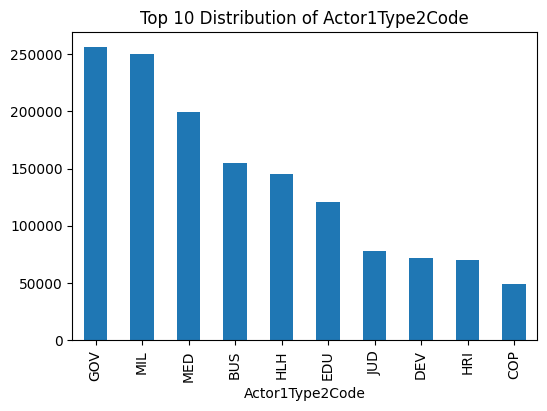

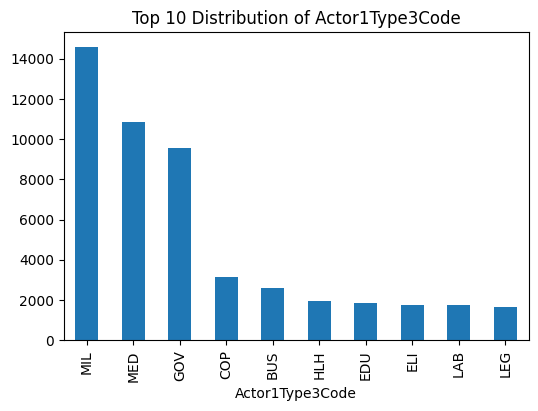

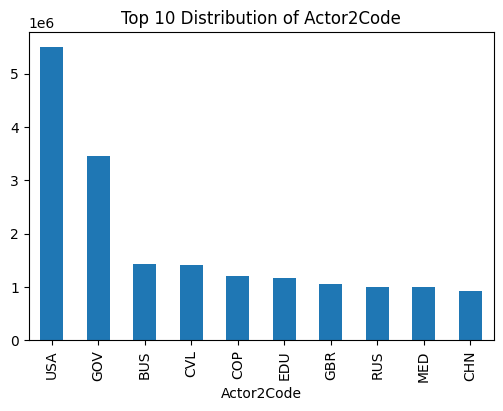

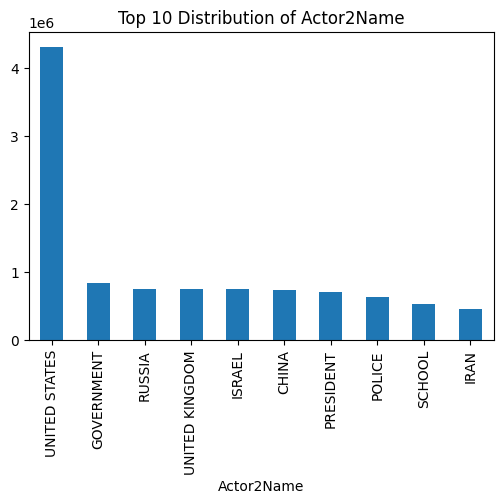

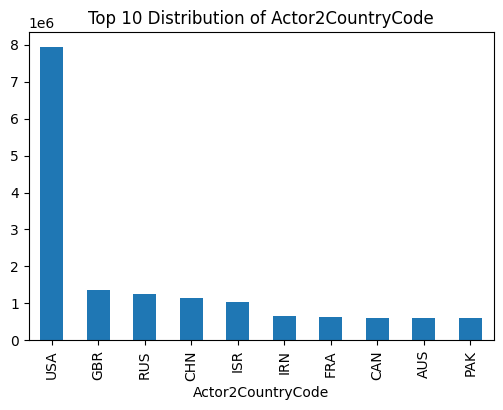

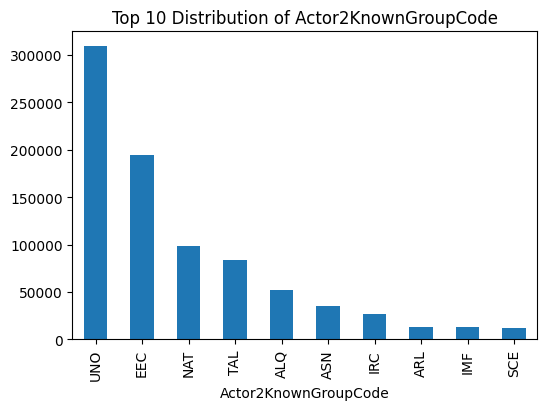

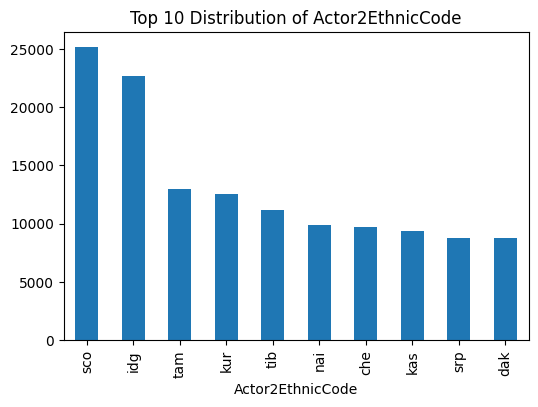

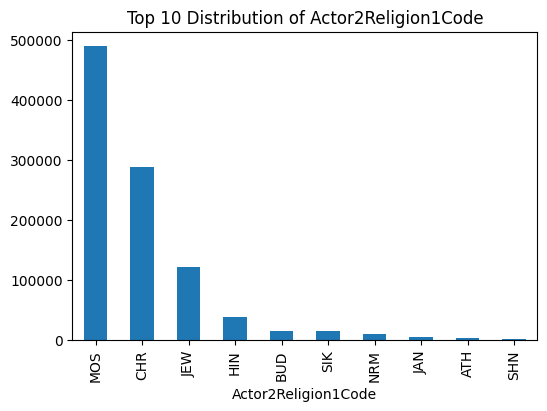

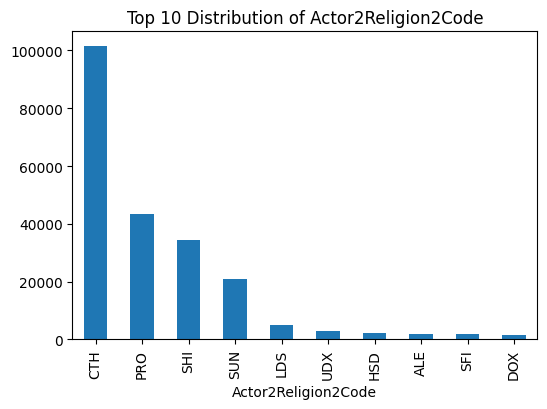

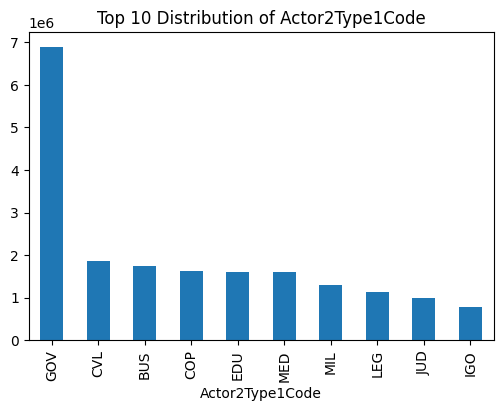

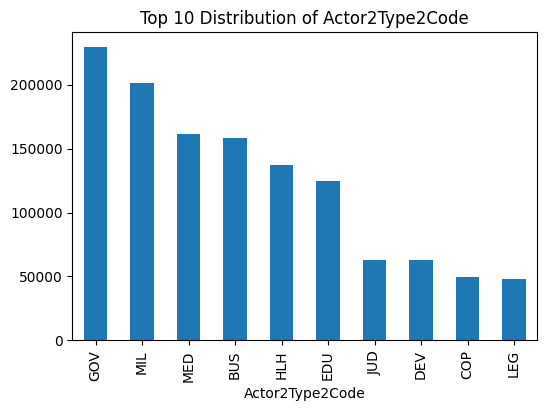

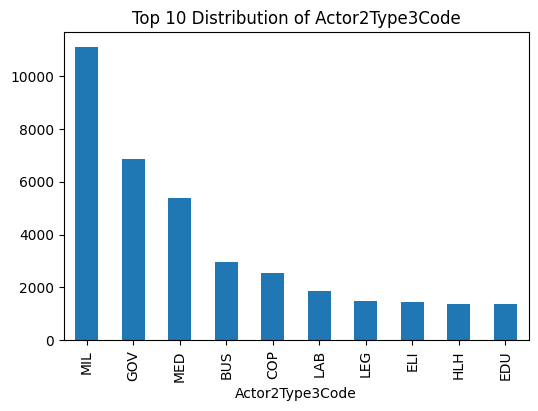

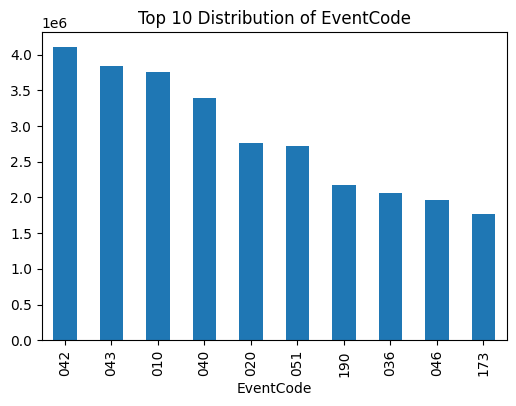

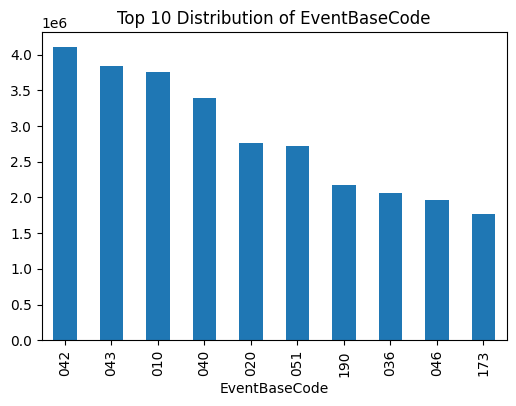

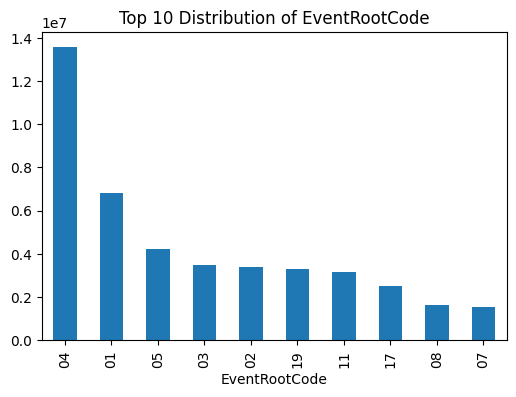

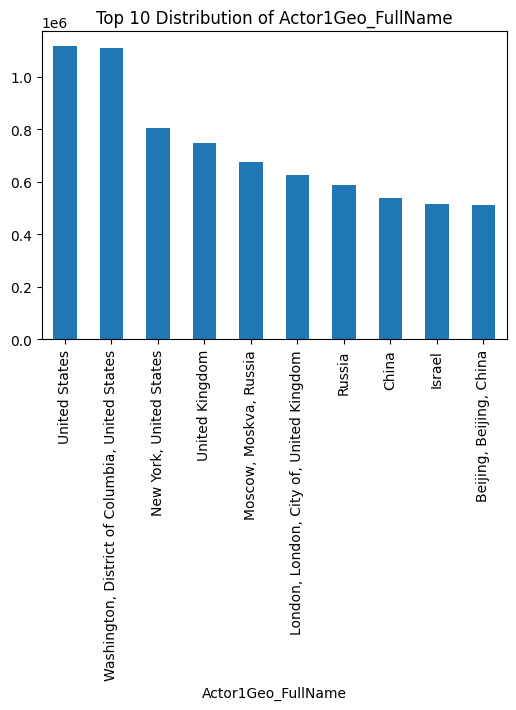

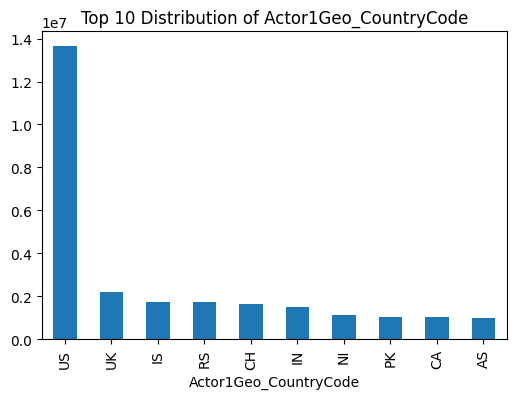

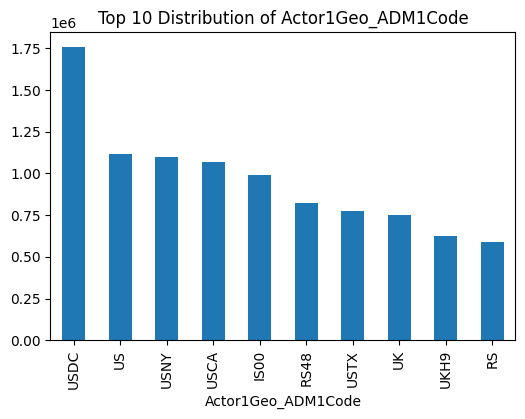

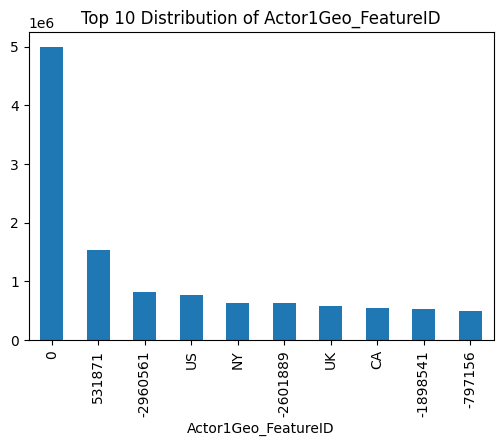

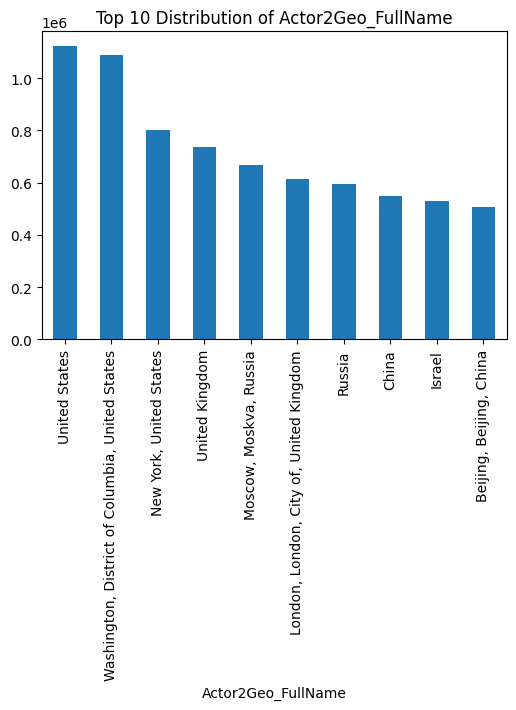

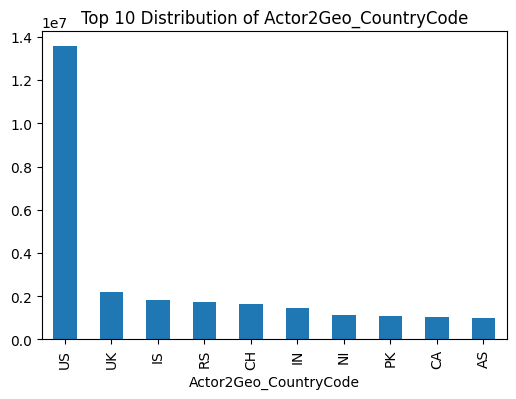

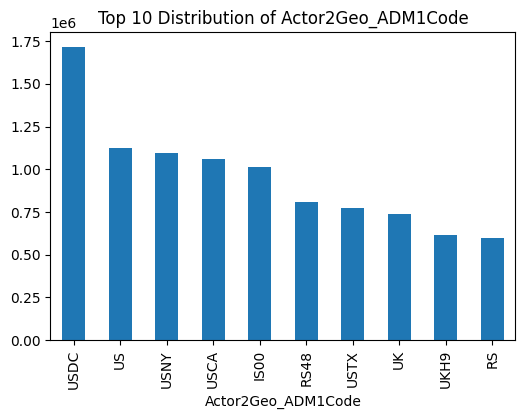

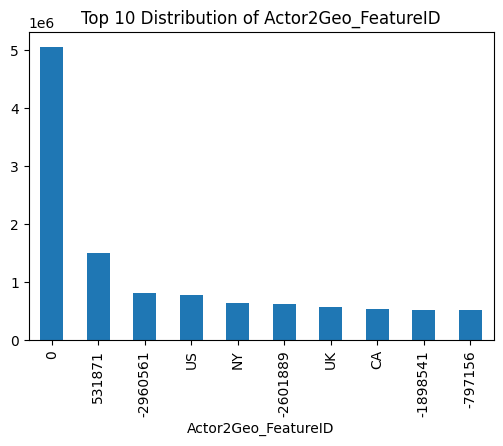

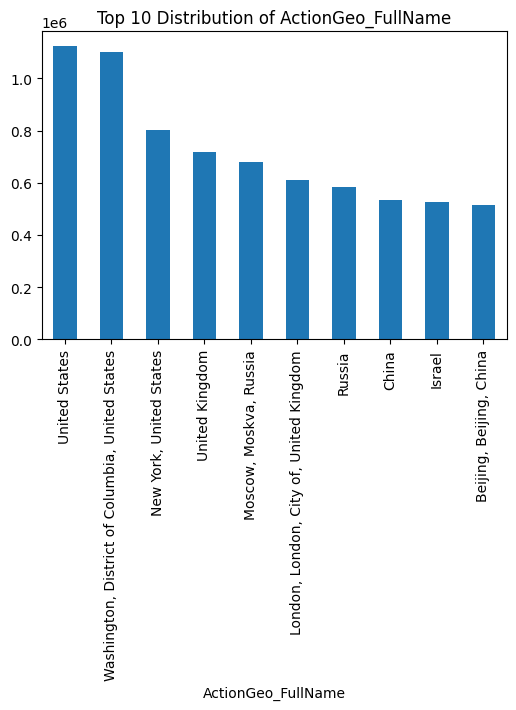

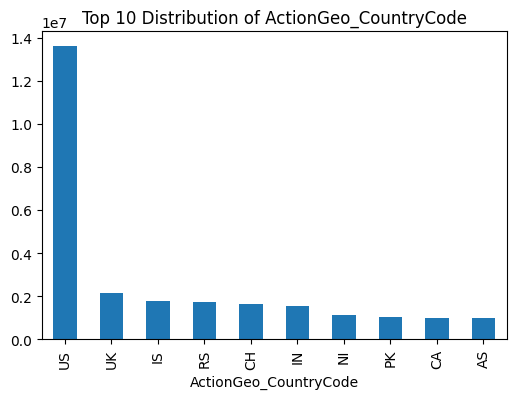

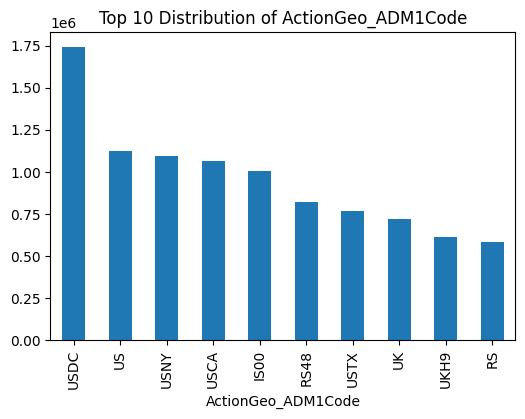

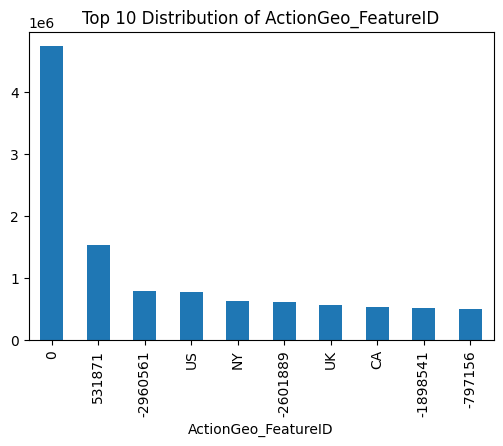

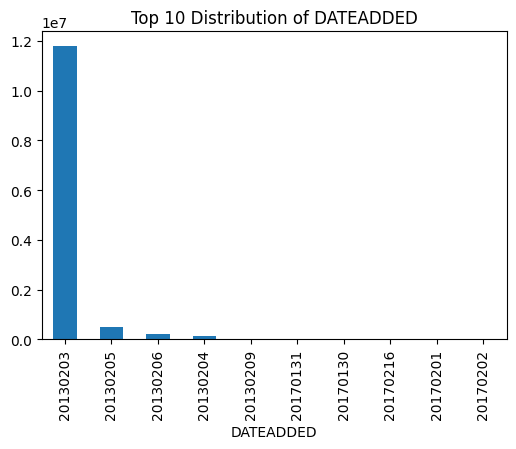

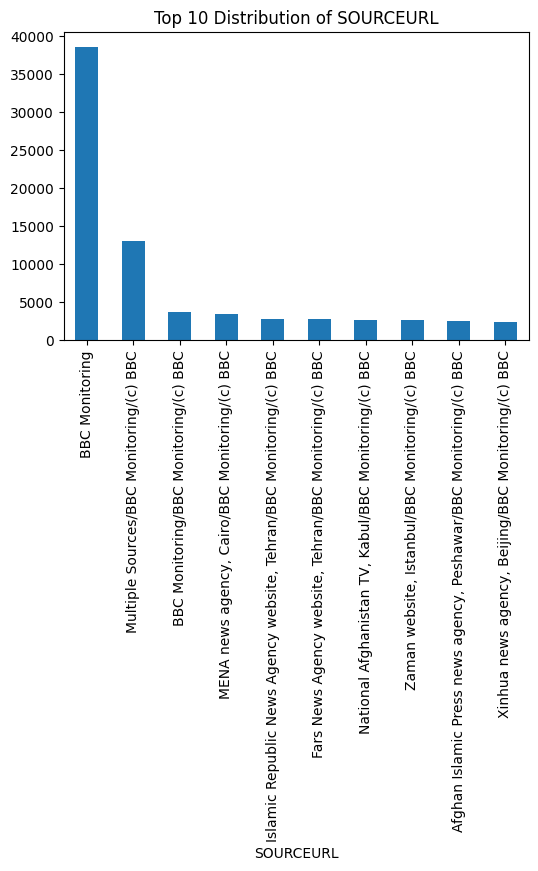

In [30]:
for col in categorical_cols.columns:
    top_10_bar_plot = df[col].value_counts().nlargest(10).plot.bar(figsize=(6,4))
    top_10_bar_plot.set_title(f"Top 10 Distribution of {col}")
    plt.show()

We can separate the features according to their nature:

- Time features: Day, MonthYear, Year, FractionDate, DATEADDED.

- Geospatial features: Actor1Geo_Lat, Actor1Geo_Long, Actor2Geo_Lat, Actor2Geo_Long, ActionGeo_Lat, ActionGeo_Long.

- Low cardinality categorical features (~50 unique values): Actor1KnownGroupCode, Actor1Religion1Code, Actor1Religion2Code, Actor1Type1Code, Actor1Type2Code, Actor1Type3Code, Actor2KnownGroupCode, Actor2Religion1Code, Actor2Religion2Code, Actor2Type1Code, Actor2Type2Code, Actor2Type3Code, **IsRootEvent**, EventRootCode, **QuadClass**, **Actor1Geo_Type**, **Actor2Geo_Type**.

> In fact, all of these are predefined CAMEO codes. Obs: The metadata indicates QuadClass' type as "integer", so its values are numeric, although it is a categorical feature. So it is the case with Actor1Geo_Type, Actor2Geo_Type. IsRootEvent is a boolean value (binary categorical feature).

- Medium cardinality categorical features (~500 unique values): Actor1CountryCode, Actor1EthnicCode, Actor2CountryCode, Actor2EthnicCode, EventCode, EventBaseCode, Actor1Geo_CountryCode, Actor2Geo_CountryCode, ActionGeo_CountryCode.

> All of these are predefined CAMEO/ISO codes as well.

- High cardinality categorical features (~5000+ unique values): Actor1Code, Actor1Name, Actor2Code, Actor2Name, Actor1Geo_FullName, Actor1Geo_ADM1Code, Actor1Geo_FeatureID, Actor2Geo_FullName, Actor2Geo_ADM1Code, Actor2Geo_FeatureID, ActionGeo_FullName, ActionGeo_ADM1Code, ActionGeo_FeatureID.

> Here, values aren't predefined, what justify the higher cardinality.

- Unsctructured features/Natural Language alike (count ~ unique): SOURCEURL

- Numerical features: GoldsteinScale, NumMentions, NumSources, NumArticles, AvgTone.


##  Correlation & Redundancy
For numerical:

Pearson/Spearman correlation matrix

Multicollinearity detection (VIF or thresholding)

For categorical:

normalized mutual information (optional)

co-occurrence matrices

In [ ]:
# --- Metric numeric features (true quantities) ---
metric_cols = [
    'GoldsteinScale',
    'NumMentions',
    'NumSources',
    'NumArticles',
    'AvgTone'
]

# --- Ordinal features ---
ordinal_cols = [
    'QuadClass',
    'EventRootCode'  # coarse hierarchy, optional
]

# --- Time-like (avoid Pearson directly) ---
time_cols = [
    'Day',
    'MonthYear',
    'Year',
    'FractionDate'
]

# --- Geographic (exclude from correlation) ---
geo_cols = [c for c in df.columns if 'Geo_' in c and
            (c.endswith('_Lat') or c.endswith('_Long'))]

# --- Identifiers / codes / text ---
exclude_cols = [
    'GlobalEventID', 'SOURCEURL', 'DATEADDED',
    'Actor1Code', 'Actor2Code',
    'Actor1Name', 'Actor2Name'
] + geo_cols


### Metric ↔ Metric correlation (Pearson or Spearman)

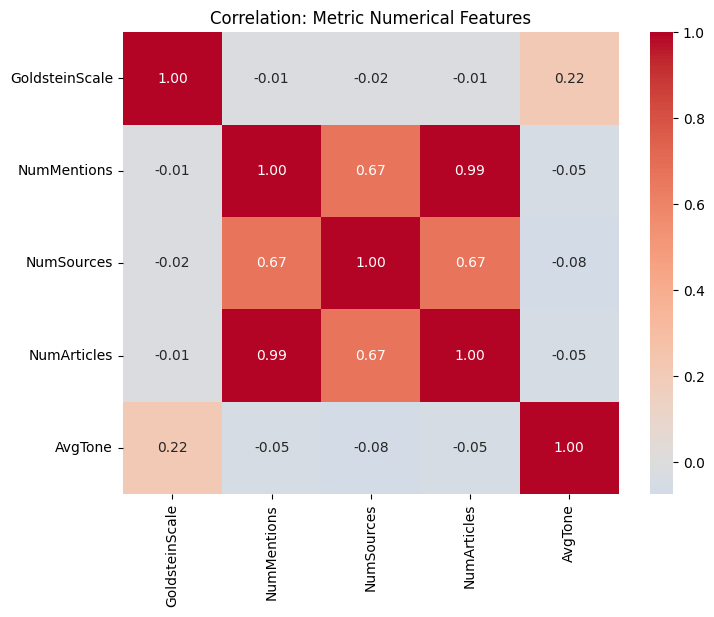

In [20]:
metric_corr = df[metric_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(metric_corr, annot=True, fmt=".2f",
            cmap='coolwarm', center=0)
plt.title("Correlation: Metric Numerical Features")
plt.show()


### Metric ↔ Ordinal

In [24]:
rows = []
for m in metric_cols:
    for o in ordinal_cols:
        rho, p = spearmanr(df[m], df[o])
        rows.append({
            'metric_feature': m,
            'ordinal_feature': o,
            'spearman_rho': rho,
            'p_value': p
        })

metric_ordinal_corr = pd.DataFrame(rows)
metric_ordinal_corr


,metric_feature,ordinal_feature,spearman_rho,p_value
0,GoldsteinScale,QuadClass,NaN,NaN
1,GoldsteinScale,EventRootCode,NaN,NaN
2,NumMentions,QuadClass,0.024637,0.0
3,NumMentions,EventRootCode,0.017493,0.0
4,NumSources,QuadClass,0.015294,0.0
5,NumSources,EventRootCode,0.005458,0.0
6,NumArticles,QuadClass,0.022920,0.0
7,NumArticles,EventRootCode,0.015291,0.0
8,AvgTone,QuadClass,-0.199151,0.0
9,AvgTone,EventRootCode,-0.134301,0.0


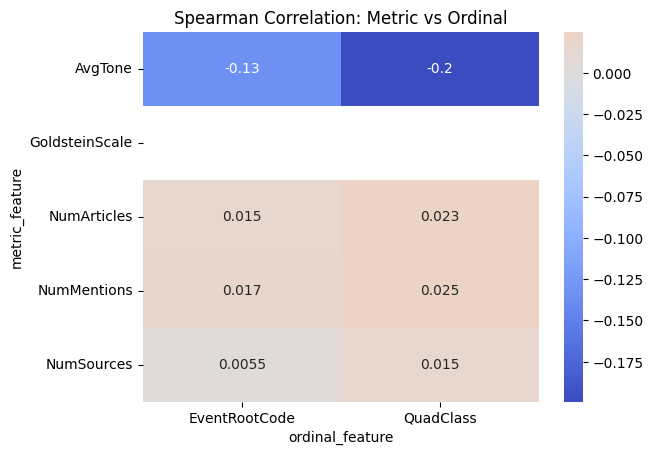

In [25]:
pivot = metric_ordinal_corr.pivot(
    index='metric_feature',
    columns='ordinal_feature',
    values='spearman_rho'
)

sns.heatmap(pivot, annot=True, cmap='coolwarm', center=0)
plt.title("Spearman Correlation: Metric vs Ordinal")
plt.show()


### Time variables

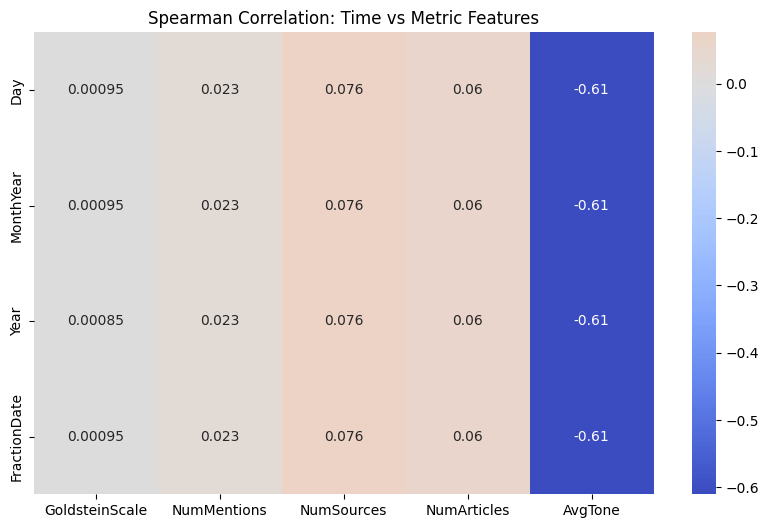

In [26]:
time_metric_corr = df[time_cols + metric_cols].corr(method='spearman')

plt.figure(figsize=(10, 6))
sns.heatmap(time_metric_corr.loc[time_cols, metric_cols],
            annot=True, cmap='coolwarm', center=0)
plt.title("Spearman Correlation: Time vs Metric Features")
plt.show()


 NOTE:
 Geographic coordinates, identifiers, and categorical codes
 are excluded from correlation analysis because Pearson/Spearman
 would be misleading or meaningless for EDA

## Temporal Analysis

Text(0.5, 1.0, 'Yearly event counts')

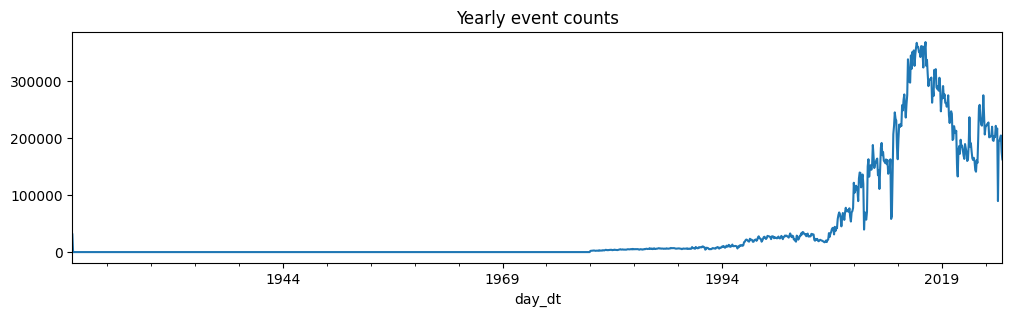

In [28]:
# cell: convert Day -> datetime
df['day_dt'] = pd.to_datetime(df['Day'].astype(str), format='%Y%m%d')
df.set_index('day_dt', inplace=False)
# events over time (daily or monthly)
df.groupby('day_dt').size().resample('ME').sum().plot(figsize=(12,3))
plt.title("Yearly event counts")

## Outliers & Anomalies

Z-score or IQR-based detection

leverage points

anomaly samples preview

## Data Quality Checks

invalid values (negative counts, impossible flags)

duplicated IDs

inconsistent categories

inconsistent timestamps (future/past impossible dates)

# Summary & Actions

The experiments will investigate **representation learning and inductive bias** across different deep learning architectures using the **GDELT Event Database**. Feature selection and modeling choices are guided by an **event-centric abstraction**, where an *Event* is treated as a first-class semantic unit for representing, interpreting, and reasoning about changes in world state as expressed in data. GDELT event data concerns geopolitical happenings. It naturally decomposes each event into four orthogonal semantic dimensions:

* **WHAT** — the action and its characteristics
* **WHEN** — the temporal context
* **WHO / WHOM** — the actors involved
* **WHERE** — the geographic context


Notice this is different from the most common 5w1h modelling: there's no "why" or "how" expressed on data, yet "whom" is seamless provided. This happens because:

> **GDELT Event records are stored in an expanded version of the dyadic CAMEO format, capturing two actors and the action performed by Actor1 upon Actor2**.

The goal is an **informative representation** aligned with these dimensions, while minimizing redundancy and noise. It's necessary to select the useful features based on this criteria.

#### Identifiers and Temporal Context (WHEN)

* **GlobalEventID**: Primary key. Retained for event identity and traceability.
* **Day**: Canonical temporal representation. Retained as the event-time variable.
* **MonthYear, Year, FractionDate**: Redundant given *Day*. Excluded.

---

#### Actor Attributes (WHO / WHOM)

Actor attributes are split between **weakly structured codes** and **regularized textual or categorical fields**.

* **Actor1Code / Actor2Code**: Compact but weakly structured CAMEO encodings. Each code concatenates multiple 3-character attributes (geographic, ethnic, religious, role-based) in arbitrary order. Informative but difficult to model directly.
* **Actor1Name / Actor2Name**: Regular textual patterns.
* **Actor1CountryCode / Actor2CountryCode**: Structured categorical signal.
* **Actor1KnownGroupCode / Actor2KnownGroupCode**: Structured categorical signal.
* **Actor1EthnicCode / Actor2EthnicCode**: Structured categorical signal.
* **Actor1Religion1Code / Actor2Religion1Code**: Structured categorical signal.
* **Actor1Religion2Code / Actor2Religion2Code**: Structured categorical signal.
* **Actor1Type1Code / Actor2Type1Code**: Structured categorical signal.
* **Actor1Type2Code / Actor2Type2Code**: Structured categorical signal.
* **Actor1Type3Code / Actor2Type3Code**: Structured categorical signal.

These fields collectively encode *who* and *whom* are involved at varying levels of specificity and structure and are therefore retained.

---

#### Action Semantics (WHAT)

* **IsRootEvent**: Binary abstraction of event primacy.
* **EventCode**: Most specific action representation.
* **EventBaseCode**: Smoothed action category.
* **EventRootCode**: Higher-level abstraction of action type.
* **QuadClass**: Coarsest action categorization.
* **GoldsteinScale**: Continuous measure of event intensity/severity.

These columns provide a semantic, hierarchical, and scalar view of *what happened*, supporting both fine-grained and coarse inductive biases. They are the best option for the target in a classification task. However, the metadata specifies that these columns are deterministically related, such that if any one of them is used as a label, the others must be excluded to avoid target leakage.

* **NumMentions, NumSources, NumArticles**: Proxies for event prominence and media salience.
* **AvgTone**: Aggregate sentiment associated with the event.

These columns provide a scalar view of *what happened*, but are currently considered legacy in the GDELT project and are therefore excluded.

---

#### Geographic Context (WHERE)

Geographic columns are provided for **Actor1**, **Actor2**, and the **Action location** itself. Each follows the same schema:

* **Geo_Type**: Granularity indicator.
* **Geo_FullName**: Textual location reference; noisy due to spelling and naming variation.
* **Geo_CountryCode**: Country-level signal; noisy but useful.
* **Geo_ADM1Code**: Administrative subdivision; noisy.
* **Geo_Lat / Geo_Long**: High-resolution spatial coordinates.
* **Geo_FeatureID**: Most specific and canonical geographic identifier.

While textual and administrative fields are noisy, **Geo_FeatureID** and latitude–longitude coordinates offer the most reliable geographic grounding for *where it happened*. These two are retained; the remaining geographic fields are excluded.

---

#### Metadata

* **DATEADDED**: Ingestion timestamp; not event-time.
* **SOURCEURL**: Traceability and provenance; not used for representation learning.

Both are excluded.

---

### Modeling Implications

* Temporal information is canonicalized around *Day*.
* Action semantics are the target of the predictive task. **QuadClass** is the most suitable label, since its cardinality is low (four classes) while still capturing meaningful distinctions between conflict and cooperation.
* Actor information benefits from **hybrid symbolic–textual modeling**. Features are often sparse (NaN), but when present they contribute meaningful signal.
* Geographic information is most precisely defined via latitude–longitude coordinates and GeoFeatureID codes.
* Redundant or weakly informative columns are excluded.


Veredict: The following columns are the necessary to be kept, so the events are well-posed:

- (Event Identifier) *GlobalEventID*;

- (WHO) *Actor1Name*, *Actor1CountryCode*, *Actor1KnownGroupCode*,
  *Actor1EthnicCode*, *Actor1Religion1Code*, *Actor1Religion2Code*,
  *Actor1Type1Code*, *Actor1Type2Code*, *Actor1Type3Code*;

- (WHOM) *Actor2Name*, *Actor2CountryCode*, *Actor2KnownGroupCode*,
  *Actor2EthnicCode*, *Actor2Religion1Code*, *Actor2Religion2Code*,
  *Actor2Type1Code*, *Actor2Type2Code*, *Actor2Type3Code*;
    
- (WHERE)*Actor1Geo_Lat*, *Actor1Geo_Long*, *Actor1Geo_FeatureID*,
    *Actor2Geo_Lat*, *Actor2Geo_Long*,*Actor2Geo_FeatureID*,
    *ActionGeo_Lat*, *ActionGeo_Long*,*ActionGeo_FeatureID*;
     
-  (WHEN) *Day*;
    
-  (WHAT)  *QuadClass*

## Data Modeling and Representational Assumptions

Before designing models, it is necessary to explicitly define the data modeling assumptions under which learning takes place.

The same underlying events can be modeled and encoded in multiple ways depending on how we assume they relate to one another and to the learning task. These assumptions determine the input representation that is ultimately fed to a model.

- When events are treated as independent, orderless observations with no explicit relational structure, the natural modeling choice is a tabular representation, and learning operates in a Euclidean feature space. Learning occurs over features interactions.

- When events are assumed to participate in a relational structure (e.g., shared actors, locations, or interactions), the data can be modeled as a graph, enabling non-Euclidean learning over nodes and edges interactions.

- When these relations evolve over time, the appropriate modeling becomes a temporal graph.

- When relations are typed and schema-constrained (e.g., actor–action–location semantics), the data can be interpreted as a knowledge graph.

- When events are viewed as symbolic or linguistic constructs, they can be encoded as natural language sequences and processed with pretrained language models such as BERT.

Each of these modeling choices induces a different representational bias: the model is encouraged to exploit specific regularities (e.g., independence, relational inductive bias, sequential structure, or linguistic compositionality) while ignoring others.

For a comparison across modeling paradigms and architectures to be meaningful, it is essential that each model is trained on semantically equivalent information, even if that information is expressed in different structural or representational forms.

For instance, the following features:

- ActionGeo_FullName

- ActionGeo_CountryCode

- ActionGeo_Lat + ActionGeo_Long

- ActionGeo_FeatureID

all encode the same underlying concept — location — albeit at different levels of granularity and through different coding schemes. While these representations are not identical, they are semantically overlapping. Using one instead of another does not fundamentally alter the informational content available to the model, as long as this choice is explicitly acknowledged.

By contrast, comparisons become invalid when one modeling receives additional non-structural information that is not present in the others. For example, a model that uses:

`Actor1Code, Actor2Code, ActionGeo_CountryCode`


cannot be meaningfully compared to one that uses:

`Actor1Code, Actor2Code, ActionGeo_CountryCode, Day`


since the latter has access to temporal information that is absent from the former. In such cases, performance differences cannot be attributed to modeling choices or inductive bias alone, but are confounded by unequal information availability. It's pivotal, therefore, to enforce feature-level semantic equivalence across all modelings: the same or an equivalent subset of GDELT fields is used to construct tabular inputs, graph structures and node features, and natural language descriptions.

By holding the informational content constant and varying only the structural form of the input, it 's possible to isolate the effect of inductive bias introduced by different architectures in their representation learning processes:

- MLPs operate in Euclidean spaces and assume independence and stationarity.

- Graph neural networks operate in non-Euclidean domains, where assumptions such as locality, compositionality, and translation invariance no longer hold.

- Transformer-based language models impose strong biases related to sequence modeling, contextual composition, and distributional semantics.

The goal of this experimental setup is not to determine which model performs best in absolute terms, but to analyze how different representational assumptions shape what is learned from the same underlying event information.



## The Tabular Representation

The tabular features for this classification task will derive from:

- (WHO) *Actor1Name*, *Actor1CountryCode*, *Actor1KnownGroupCode*,
  *Actor1EthnicCode*, *Actor1Religion1Code*, *Actor1Religion2Code*,
  *Actor1Type1Code*, *Actor1Type2Code*, *Actor1Type3Code*;

- (WHOM) *Actor2Name*, *Actor2CountryCode*, *Actor2KnownGroupCode*,
  *Actor2EthnicCode*, *Actor2Religion1Code*, *Actor2Religion2Code*,
  *Actor2Type1Code*, *Actor2Type2Code*, *Actor2Type3Code*;
    
- (WHERE)*Actor1Geo_Lat*, *Actor1Geo_Long*, *Actor1Geo_FeatureID*,
    *Actor2Geo_Lat*, *Actor2Geo_Long*,*Actor2Geo_FeatureID*,
    *ActionGeo_Lat*, *ActionGeo_Long*,*ActionGeo_FeatureID*;
     
-  (WHEN) *Day*;
    
As the target is (WHAT) *QuadClass*.

> Disclaimer: QuadClass is kind of ordinal: The numeric codes in this field map to the Quad Classes as follows: 1=Verbal Cooperation, 2=Material Cooperation, 3=Verbal Conflict, 4=Material Conflict. Verbal -> Material; Cooperation -> Conflict. This makes the evaluation a trickier, as mislabelling Verbal Cooperation & Material Conflict is much worser than any other mislabelling.

### Encoding High-Cardinality Categorical Features

Most of the features used in this project are categorical. However, these categorical variables differ along two dimensions: observed cardinality and semantic regularity.

From an exploratory standpoint, features such as Actor1Name, Actor1Geo_FeatureID, and Actor1CountryCode already differ significantly in their empirical cardinality, as shown in the EDA. More importantly, they also differ in their semantic nature.

Some categorical features are defined over a pre-specified and relatively stable vocabulary of codes provided by GDELT: *Actor1CountryCode*, *Actor1KnownGroupCode*, *Actor1EthnicCode*, *Actor1Religion1Code*, *Actor1Religion2Code*, *Actor1Type1Code*, *Actor1Type2Code*, *Actor1Type3Code* and their Actor2 counterparts

Although some of these features may still exhibit moderately high cardinality, their values are drawn from known codebooks with well-defined semantics and limited long-tail behavior. As a result, their distribution is prone to be relatively stable across train, validation, and test splits, and the appearance of previously unseen categories is limited.

By contrast, other categorical features are not governed by a fixed or enumerable vocabulary, even if their theoretical domain is finite:
*Actor1Name*, *Actor2Name*, *Actor1Geo_FeatureID*, *Actor2Geo_FeatureID* and *ActionGeo_FeatureID*.

While actors and geographic entities are finite in principle, their identifiers do not follow a compact or regularly reused code scheme. These features exhibit extreme cardinality, strong sparsity, and a pronounced long-tail distribution. Consequently, a non-negligible fraction of categories observed at validation or test time may be unseen during training, making naïve encoding strategies brittle.

### Encoding Strategy and Design Choices

A one-hot encoding is infeasible for both groups of categorical features. Even for predefined code-based variables, the combined dimensionality across all categorical columns would result in extremely sparse and memory-intensive representations, without clear benefits for model performance. For open-vocabulary features, one-hot encodings are prohibitively large and particularly vulnerable to out-of-vocabulary issues.

For this reason, categorical features must be encoded using either:

- a Label Encoding scheme, augmented with an explicit unknown (UNK) category to handle values not observed during training; or

- a Hash Encoding scheme that maps categories to integer indices within a fixed range.

Label encoding is particularly appropriate for features derived from closed or standardized code systems, such as CAMEO or ISO-based codes. In these cases, the set of valid categories is defined by an external specification, and the absence of a given code from the training split does not imply that the code is semantically distinct in an open-ended way. Treating all unseen codes as a single UNK category is therefore a reasonable modeling assumption: it reflects the fact that the model has no evidence to distinguish among these values and should not be encouraged to do so. In other words, collapsing unseen categories into a shared representation expresses epistemic uncertainty rather than semantic equivalence.

By contrast, features drawn from open-world vocabularies—such as actor names or fine-grained geographic identifiers—do not admit a stable or enumerable set of possible values. In this setting, unseen categories at validation or test time are not exceptional, but expected. Using a single UNK token would artificially conflate potentially distinct entities, introducing an undesirable inductive bias that forces the model to treat all novel values as identical.

Hash encoding offers a practical compromise in this scenario. By mapping categories into a fixed index space via a hash function, unseen values are deterministically assigned to indices without collapsing them into a single representation. While hash collisions may occur, they are stochastic and evenly distributed, and therefore preferable to systematically conflating all unseen categories. This allows the model to maintain a degree of distinction among novel entities while keeping memory usage bounded.

Overall, label encoding with an explicit unknown category is used when semantic closure can be reasonably assumed, whereas hash encoding is preferred for open-world categorical domains, where novelty is intrinsic and should not be treated as a single undifferentiated state.

Both encoders output scalar indices, which are not intended to be interpreted as ordinal or metric quantities. Using such scalar encodings directly would introduce artificial notions of distance (e.g., implying that category $4$ is closer to $3$ than to $1$), which is semantically meaningless for nominal data.

To avoid this issue, all models that consume categorical encodings are equipped with learned embedding layers. These embeddings map discrete indices into dense vector representations, allowing models to learn task-relevant similarities between categories without imposing spurious ordering constraints.

This design preserves computational efficiency, explicitly handles unseen categories, and ensures that categorical variables are treated as symbolic identifiers rather than numeric quantities. Notably, each model learns its own embedding space as part of its optimization process. As a result, different architectures may induce different latent representations for the same categorical inputs at test time.

Rather than weakening the comparison across modeling paradigms, this choice strengthens the study of representation learning: by fixing the symbolic input space while allowing embeddings to be learned end-to-end, differences in performance can be attributed to how each architecture transforms identical discrete information into task-relevant representations, rather than to handcrafted or shared feature encodings.

### Transforming Geodesic Data into Euclidean Data

Raw geographic coordinates—such as *Actor1Geo_Lat*, *Actor1Geo_Long*, *Actor2Geo_Lat*, *Actor2Geo_Long*, and *ActionGeo_Lat*, *ActionGeo_Long*—are not well suited to be used directly as numerical inputs to an MLP.

Latitude and longitude are angular coordinates defined on the surface of a sphere, not points in a Euclidean vector space. Treating them as ordinary real-valued features implicitly assumes a flat geometry and linear distance relationships that do not hold on the Earth’s surface. As a result, standard operations performed by MLPs—such as affine transformations and inner products—can lead to misleading geometric interpretations.

A canonical example is the discontinuity at the $\pm 180°$ meridian: longitudes of $−180°$ and $+180°$ correspond to nearly identical physical locations, yet a model operating in $\mathbb{R}^2$ would interpret them as maximally distant along that axis. More generally, Euclidean distances and dot products in the (latitude, longitude) coordinate system do not correspond to meaningful geodesic distances or angular relationships on the sphere.

To mitigate this issue, latitude and longitude pairs must be transformed into three-dimensional Euclidean coordinates lying on an sphere. This is achieved by mapping each (lat, long) pair to an (x, y, z) representation using standard spherical-to-Cartesian transformations. In this representation, geographic proximity is more faithfully reflected by Euclidean distances and inner products, and the discontinuities inherent to angular coordinates are removed.

This transformation allows MLPs to operate on geographic information in a way that is compatible with their underlying assumptions about Euclidean geometry, without introducing additional relational structure or external geographic priors.

> For optimization stability, the resulting (x, y, z) coordinates are standard-scaled. Since this scaling normalizes feature magnitudes, the absolute radius of the sphere does not affect learning; only the relative angular geometry encoded by the coordinates is preserved. 

> Other choices of scaling, like Robust Scale, can be applied, but standard scale already works well as (x,y,z) are naturally bounded.

### Transforming Temporal Information as Cyclic Features

The feature *Day* encodes temporal information that is inherently periodic. Treating it as a raw integer would implicitly impose an ordinal and linear structure, suggesting that consecutive days are equally spaced in time and that the first and last days of a period are maximally distant—assumptions that are not appropriate for cyclical temporal phenomena.

To preserve the periodic nature of time while remaining compatible with Euclidean models such as MLPs, the *Day* feature must be transformed into a cyclic representation using sine and cosine functions. This transformation would remove artificial discontinuities at period boundaries (e.g., between the last and first day of a cycle) and ensures that temporal proximity is reflected by geometric proximity in feature space. Moreover, the sin–cos encoding does not impose an arbitrary ordering or distance scale on time, allowing models to learn periodic patterns without conflating them with linear trends.

## The Graph Representations

Events are modeled using graph structures in order to explicitly encode relational dependencies between them. The graph constructions are derived exclusively from the same subset of event attributes used in the tabular and textual pipelines, ensuring that no additional semantic information is introduced at the modeling stage.

Two graph modelings are considered: a homogeneous event graph and a heterogeneous event–component graph.

### Homogeneous Event Graph

In the homogeneous setting, each node represents an event. Edges can be introduced between pairs of events if they share at least one of the following components:

- (WHO) Actor1ID

- (WHOM) Actor2ID

- (WHERE) Event_GeoID

- (WHEN) Day

Intuitively, two events are considered related if they involve the same actor, occur at the same location, or take place on the same day. The resulting graph captures event–event proximity induced by shared attributes, without explicitly representing those attributes as separate entities.

Edges must be undirected and unweighted. It reflects the fact that the relations encode mutual co-occurrence rather than directional or asymmetric interactions, and it aligns with the assumptions made by most standard graph neural network architectures, which operate on simple, undirected graphs.

> The graph encodes **higher-order similarity**, not causality or temporality.

Since inductive bias is a object of study, node features can vary across experimental settings. In some configurations, event nodes can be initialized with the same feature vectors used in the tabular models; in others, no node features are provided, forcing the model to rely solely on the graph structure. In all cases, node labels correspond to the event-level QuadClass, and the task is framed as node classification: GNN + linear head.

> There's an equivalence between (dataframe) instance classification <-> node classification, since nodes are derived from instances, which in turn represent events.

By considering a final layer as a linear head, it's possible to measure how well the modelling + model duo is capable of provide a linear separable representation of the classes for the classification task.


### Heterogeneous Event–Component Graph

In the heterogeneous setting, the same components used to define edges in the homogeneous graph can be instead modeled as explicit nodes. The graph includes multiple node types:

- Event nodes 

- Actor nodes (WHO/WHOM)

- Geographic nodes (WHERE)

- Temporal (day) nodes (WHEN)

Edges must be typed and represent semantic relations such as has_actor1, has_actor2, has_location, and has_day. Events connect only to their associated components, resulting in a bipartite graph structure between event nodes and component nodes. No direct edges exist between events themselves.

As in the homogeneous case, edges are undirected and unweighted. Directionality and edge weights are deliberately omitted to avoid injecting additional relational assumptions beyond attribute membership, and to ensure compatibility with commonly used heterogeneous graph learning frameworks.

Only event nodes are associated with labels (QuadClass). Node features are assigned to event nodes following the same rules as in the homogeneous setting, while component nodes may be initialized with minimal identifiers, depending on the experimental configuration.

## The Text Representation

Events can be modeled as natural language descriptions, enabling the use of pretrained language models and their associated linguistic inductive biases. For each event instance, a textual description can be constructed using the original, non-engineered column values. Categorical codes (e.g., CAMEO actor types, group codes, geographic identifiers) can be translated into their corresponding human-readable descriptions using predefined dictionaries. These descriptions can be then composed into short, structured sentences that explicitly verbalize the event’s participants, location, and time.

A typical example takes the form:

“[WHO] Senator (legislative body) was involved with [WHOM] New York from United States.
[WHERE] Russia.
[WHEN] January 1979.”

The textual template is deliberately simple and consistent across instances. Special markers such as [WHO], [WHOM], [WHERE], and [WHEN] can be inserted to provide weak structural cues while remaining within the natural language input format expected by transformer-based models. No additional information beyond the selected feature subset is introduced.

Actor descriptions are constructed by combining the actor’s name (when available) with translated role, group, ethnic, religious, and geographic attributes. Location and temporal information are verbalized in a normalized, human-readable form. When certain attributes are missing, the corresponding phrases are omitted, resulting in variable-length but semantically aligned texts.

These textual representations can be then used as inputs to a language model that learns a representation for a linear classification head.

## Obs

`Besides the modeling choices do have different complexity, this is mostly due to the fact representations are different. We seeked to propose the most straightfoward modelling possible given each representation (tabular, graph and text).`'